# EDA: Default of Credit Card Clients

Исследование исходного датасета кредитного дефолта. Данные загружаются в `df` без очистки и изменения названий столбцов.

Запускайте ноутбук с Python из окружения проекта `.venv`. Если CSV отсутствует, он будет скачан через KaggleHub (потребуется доступ к интернету).

In [1]:
from pathlib import Path
import sys


from IPython.display import display


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from catboost import CatBoostClassifier, Pool
import numpy as np

# Поддерживаем запуск из корня проекта и из папки notebooks.
current_dir = Path.cwd().resolve()
project_dir = next(
    (path for path in (current_dir, *current_dir.parents)
     if (path / "src/config.py").is_file() and (path / "pyproject.toml").is_file()),
    None,
)
if project_dir is None:
    raise FileNotFoundError("Откройте ноутбук из корня проекта или папки notebooks.")
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

from src.config import RAW_DATA_PATH

pd.set_option("display.max_columns", 30)

In [2]:
if not RAW_DATA_PATH.is_file():
    from src.data.make_dataset import load_data

    load_data()

df = pd.read_csv(RAW_DATA_PATH)
print(f"Датасет: {RAW_DATA_PATH.name}")
print(f"Размер: {df.shape[0]:,} строк, {df.shape[1]} столбца")
display(df.head())

Датасет: UCI_Credit_Card.csv
Размер: 30,000 строк, 25 столбца


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Структура и качество данных

In [3]:
df.info()
print(f"Полных дубликатов строк: {df.duplicated().sum()}")
display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
}))

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

,dtype,missing,unique
ID,int64,0,30000
LIMIT_BAL,float64,0,81
SEX,int64,0,2
EDUCATION,int64,0,7
MARRIAGE,int64,0,4
AGE,int64,0,56
PAY_0,int64,0,11
PAY_2,int64,0,11
PAY_3,int64,0,11
PAY_4,int64,0,11


## Описательная статистика

In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


## Целевая переменная

`default.payment.next.month`: 1 — дефолт, 0 — отсутствие дефолта.

In [5]:
target = "default.payment.next.month"
target_counts = df[target].value_counts().sort_index()
display(pd.DataFrame({
    "count": target_counts,
    "share": target_counts / len(df),
}))

,count,share
default.payment.next.month,,
0,23364,0.7788
1,6636,0.2212


## Обучение на CATBOOST без новых признаков

#Отчистка данных

In [6]:
from src.data.clean_dataset import clean_data

In [7]:
df = clean_data(df)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         30000 non-null  int64  
 1   limit_bal  30000 non-null  float64
 2   sex        30000 non-null  int64  
 3   education  30000 non-null  int64  
 4   marriage   30000 non-null  int64  
 5   age        30000 non-null  int64  
 6   pay_0      30000 non-null  int64  
 7   pay_2      30000 non-null  int64  
 8   pay_3      30000 non-null  int64  
 9   pay_4      30000 non-null  int64  
 10  pay_5      30000 non-null  int64  
 11  pay_6      30000 non-null  int64  
 12  bill_amt1  30000 non-null  float64
 13  bill_amt2  30000 non-null  float64
 14  bill_amt3  30000 non-null  float64
 15  bill_amt4  30000 non-null  float64
 16  bill_amt5  30000 non-null  float64
 17  bill_amt6  30000 non-null  float64
 18  pay_amt1   30000 non-null  float64
 19  pay_amt2   30000 non-null  float64
 20  pay_amt3   30000 

In [9]:

# Define target variable and features
X = df.drop(['default','id'], axis=1)
y = df['default']

# Identify categorical features by their column names or indices
NUMERIC_FEATURES = (
    ["limit_bal", "age"]
    + [f"bill_amt{i}" for i in range(1, 7)]
    + [f"pay_amt{i}" for i in range(1, 7)]
    + [f"avg_exp_{i}" for i in range(1, 6)]
)
CATEGORICAL_FEATURES = [
    "sex",
    "education",
    "marriage",
    "pay_0",
    "pay_2",
    "pay_3",
    "pay_4",
    "pay_5",
    "pay_6",
]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (24000, 23)
Test set shape: (6000, 23)


In [10]:
# Instantiate the CatBoostClassifier
model = CatBoostClassifier(
    loss_function='Logloss', # Objective function
    eval_metric='AUC',       # Metric for evaluation during training
    random_seed=42,          # For reproducibility
    verbose=100              # Print progress every 100 iterations
)

# Train the model
# Pass categorical feature indices directly to the fit method
model.fit(
    X_train, y_train,
    cat_features=CATEGORICAL_FEATURES,
    eval_set=(X_test, y_test), # Provide evaluation set for early stopping and metrics
    early_stopping_rounds=50   # Stop if eval_metric doesn't improve for 50 rounds
)

# Make predictions on the test set
y_pred_proba = model.predict_proba(X_test)[:, 1] # Get probability for the positive class
y_pred_class = model.predict(X_test)

# Evaluate the model precision_score, recall_score, f1_score
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)
auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred_class)

print(f"\nModel Evaluation:")
print(f"Test Set Accuracy: {accuracy:.4f}")
print(f"precision: {precision:.4f}")
print(f"recall: {recall:.4f}")
print(f"f1_score: {f1:.4f}")
print(f"auc: {auc:.4f}")



Learning rate set to 0.069474
0:	test: 0.7447809	best: 0.7447809 (0)	total: 61.6ms	remaining: 1m 1s
100:	test: 0.7764348	best: 0.7764348 (100)	total: 1.18s	remaining: 10.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7780589031
bestIteration = 149

Shrink model to first 150 iterations.

Model Evaluation:
Test Set Accuracy: 0.8192
precision: 0.6662
recall: 0.3655
f1_score: 0.4720
auc: 0.7781


##  Важные фичи

In [11]:
feature_importances = model.get_feature_importance(prettified=True)
feature_importances.columns

Index(['Feature Id', 'Importances'], dtype='str')

<Axes: xlabel='Importances', ylabel='Feature Id'>

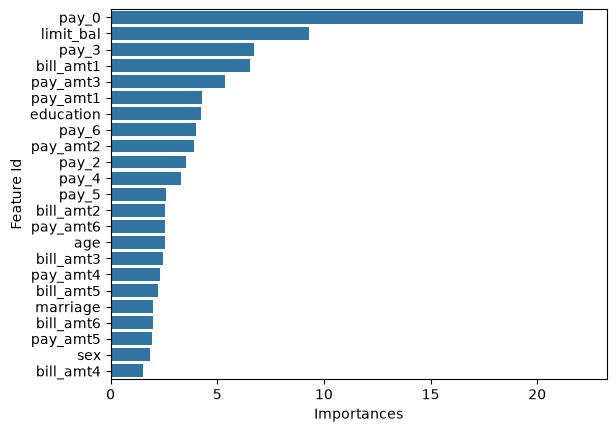

In [12]:
import seaborn as sns
sns.barplot(y = feature_importances['Feature Id'], x = feature_importances['Importances'])

## Фичеринжиниринг

In [13]:
from src.features.build_features import build_features

df_features = build_features(df).copy()

In [14]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         30000 non-null  int64  
 1   limit_bal  30000 non-null  float64
 2   sex        30000 non-null  int64  
 3   education  30000 non-null  int64  
 4   marriage   30000 non-null  int64  
 5   age        30000 non-null  int64  
 6   pay_0      30000 non-null  int64  
 7   pay_2      30000 non-null  int64  
 8   pay_3      30000 non-null  int64  
 9   pay_4      30000 non-null  int64  
 10  pay_5      30000 non-null  int64  
 11  pay_6      30000 non-null  int64  
 12  bill_amt1  30000 non-null  float64
 13  bill_amt2  30000 non-null  float64
 14  bill_amt3  30000 non-null  float64
 15  bill_amt4  30000 non-null  float64
 16  bill_amt5  30000 non-null  float64
 17  bill_amt6  30000 non-null  float64
 18  pay_amt1   30000 non-null  float64
 19  pay_amt2   30000 non-null  float64
 20  pay_amt3   30000 

In [15]:
df_features.columns

Index(['id', 'limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0',
       'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2',
       'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1',
       'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'default',
       'se_ma_2', 'agebin', 'avg_exp_5', 'avg_exp_4', 'avg_exp_3', 'avg_exp_2',
       'avg_exp_1'],
      dtype='str')

In [18]:

NUMERIC_FEATURES = (
    ["limit_bal", "age"]
    + [f"bill_amt{i}" for i in range(1, 7)]
    + [f"pay_amt{i}" for i in range(1, 7)]
    + [f"avg_exp_{i}" for i in range(1, 6)]
)
CATEGORICAL_FEATURES = [
    "sex",
    "education",
    "marriage",
    "pay_0",
    "pay_2",
    "pay_3",
    "pay_4",
    "pay_5",
    "pay_6",
    "se_ma_2",
    "agebin",
]

# Define target variable and features
X = df_features.drop(['default','id'], axis=1)
y = df_features['default']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")



# Instantiate the CatBoostClassifier
model = CatBoostClassifier(
    loss_function='Logloss', # Objective function
    eval_metric='AUC',       # Metric for evaluation during training
    random_seed=42,          # For reproducibility
    verbose=100              # Print progress every 100 iterations
)

# Train the model
# Pass categorical feature indices directly to the fit method
model.fit(
    X_train, y_train,
    cat_features=CATEGORICAL_FEATURES,
    eval_set=(X_test, y_test), # Provide evaluation set for early stopping and metrics
    early_stopping_rounds=50   # Stop if eval_metric doesn't improve for 50 rounds
)

# Make predictions on the test set
y_pred_proba = model.predict_proba(X_test)[:, 1] # Get probability for the positive class
y_pred_class = model.predict(X_test)


# Evaluate the model precision_score, recall_score, f1_score
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)
auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred_class)

print(f"\nModel Evaluation:")
print(f"Test Set Accuracy: {accuracy:.4f}")
print(f"precision: {precision:.4f}")
print(f"recall: {recall:.4f}")
print(f"f1_score: {f1:.4f}")
print(f"auc: {auc:.4f}")



Training set shape: (24000, 30)
Test set shape: (6000, 30)
Learning rate set to 0.069474
0:	test: 0.7444507	best: 0.7444507 (0)	total: 15.8ms	remaining: 15.8s
100:	test: 0.7783244	best: 0.7784581 (99)	total: 1.36s	remaining: 12.1s
200:	test: 0.7806379	best: 0.7806663 (195)	total: 2.61s	remaining: 10.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7810210527
bestIteration = 227

Shrink model to first 228 iterations.

Model Evaluation:
Test Set Accuracy: 0.8188
precision: 0.6657
recall: 0.3632
f1_score: 0.4700
auc: 0.7810


<Axes: xlabel='Importances', ylabel='Feature Id'>

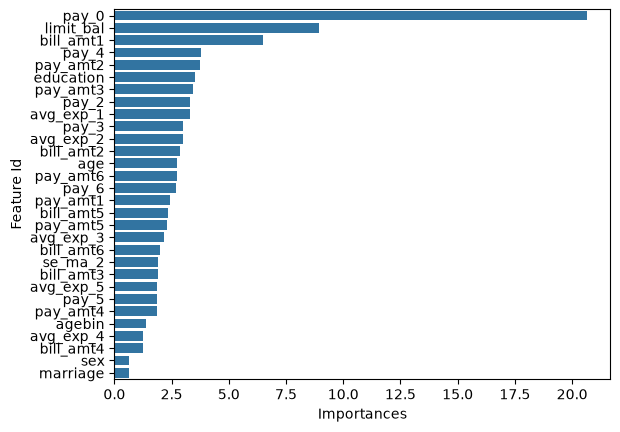

In [17]:
feature_importances = model.get_feature_importance(prettified=True)
sns.barplot(y = feature_importances['Feature Id'], x = feature_importances['Importances'])